
## Fashion-MNIST Classification: Complete Implementation ANN vs CNN Comparative Analysis

## Importing Packages

In [12]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split

In [2]:
# Random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

In [3]:
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. LOAD AND EXPLORE DATASET

In [4]:
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

# Class names
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [5]:
print(f"Training data shape: {X_train_full.shape}")
print(f"Training labels shape: {y_train_full.shape}")
print(f"Test data shape: {X_test.shape}")
print(f"Test labels shape: {y_test.shape}")
print(f"Number of classes: {len(class_names)}")
print(f"Pixel value range: [{X_train_full.min()}, {X_train_full.max()}]")

Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Test data shape: (10000, 28, 28)
Test labels shape: (10000,)
Number of classes: 10
Pixel value range: [0, 255]


In [6]:
# Check data types
print(f"X_train_full dtype: {X_train_full.dtype}")
print(f"y_train_full dtype: {y_train_full.dtype}")

X_train_full dtype: uint8
y_train_full dtype: uint8


In [7]:
# Checking the number of unique classes in the training labels
print(f"Number of unique classes in y_train_full: {len(np.unique(y_train_full))}")

Number of unique classes in y_train_full: 10


In [8]:
# Calculating class counts in the training data
class_counts = pd.Series(y_train_full).value_counts().sort_index()
# Storing the original integer indices
original_indices = class_counts.index
print("Class counts in training data (before mapping names):")
print(class_counts)

Class counts in training data (before mapping names):
0    6000
1    6000
2    6000
3    6000
4    6000
5    6000
6    6000
7    6000
8    6000
9    6000
Name: count, dtype: int64


In [9]:
# Map class indices to class names
class_counts.index = [class_names[i] for i in class_counts.index]
print("\nClass counts with names in training data:")
print(class_counts)


Class counts with names in training data:
T-shirt/top    6000
Trouser        6000
Pullover       6000
Dress          6000
Coat           6000
Sandal         6000
Shirt          6000
Sneaker        6000
Bag            6000
Ankle boot     6000
Name: count, dtype: int64


## 2. DATA PREPROCESSING

In [13]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.2,
    random_state=42,
    stratify=y_train_full  # Ensures balanced class distribution
)

In [15]:
print("DATA SPLIT")
print(f"Training set: {X_train.shape[0]} samples (stratified)")
print(f"Validation set: {X_val.shape[0]} samples (stratified)")
print(f"Test set: {X_test.shape[0]} samples")

DATA SPLIT
Training set: 48000 samples (stratified)
Validation set: 12000 samples (stratified)
Test set: 10000 samples


In [16]:
# Normalizing pixel values to [0, 1]
X_train = X_train.astype('float32') / 255.0
X_val = X_val.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

print("Normalization complete: Pixel values scaled to [0, 1]")

Normalization complete: Pixel values scaled to [0, 1]


## 3. VISUALIZE SAMPLE IMAGES

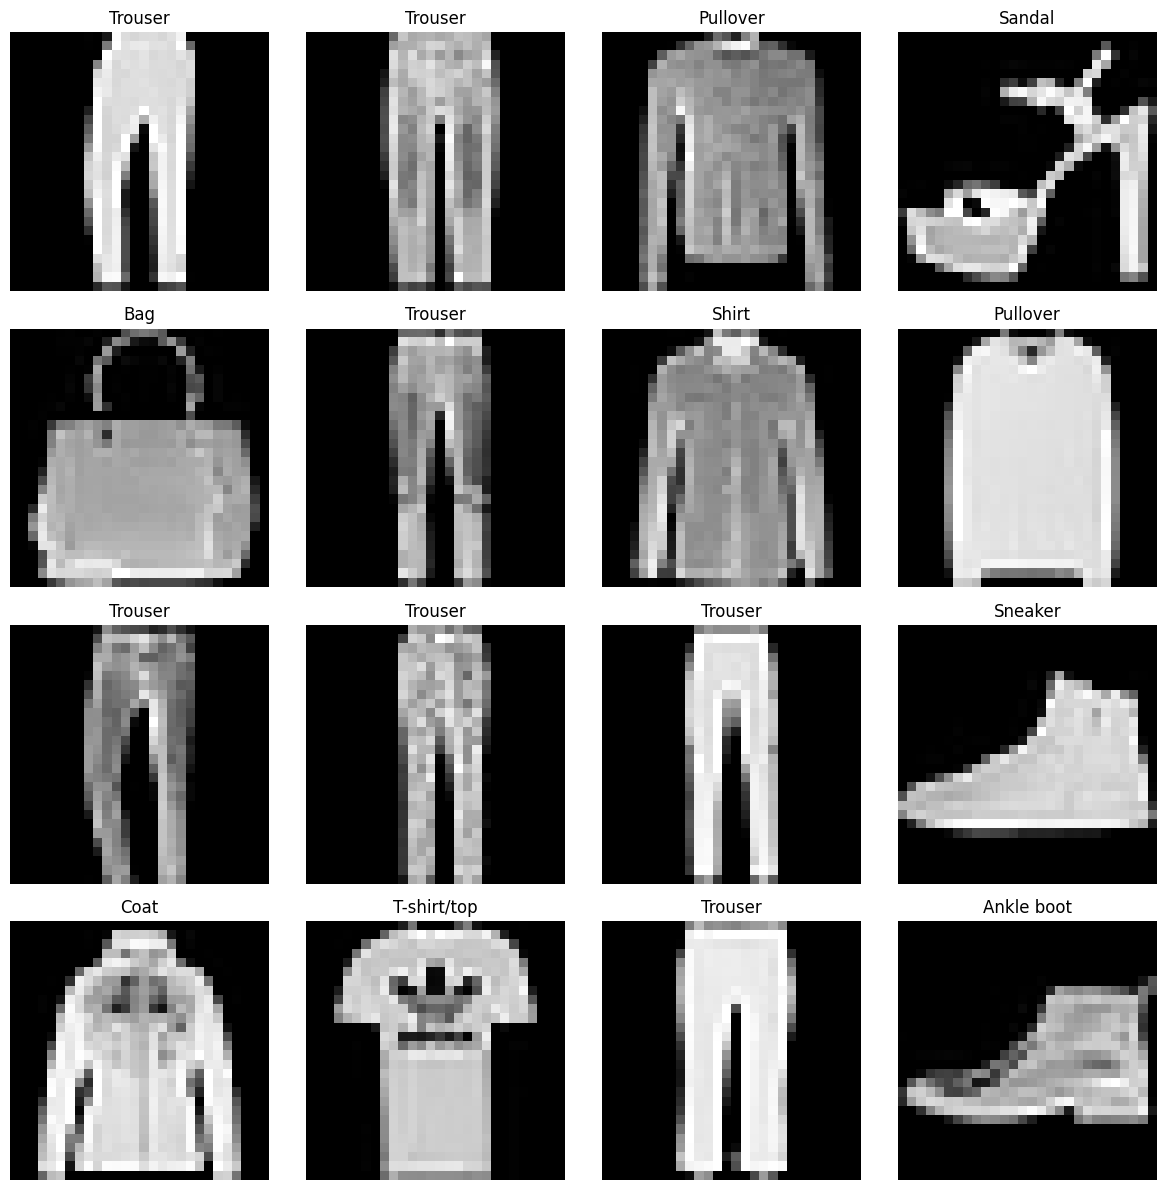


✓ Sample images saved as 'sample_images.png'


In [18]:
def visualize_samples(images, labels, class_names, n_samples=16):
    """Visualize random samples from dataset"""
    plt.figure(figsize=(12, 12))
    indices = np.random.choice(len(images), n_samples, replace=False)

    for i, idx in enumerate(indices):
        plt.subplot(4, 4, i + 1)
        plt.imshow(images[idx], cmap='gray')
        plt.title(f"{class_names[labels[idx]]}")
        plt.axis('off')
    plt.tight_layout()
    plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\n✓ Sample images saved as 'sample_images.png'")

visualize_samples(X_train, y_train, class_names)

## 4. MODEL 1: ARTIFICIAL NEURAL NETWORK (ANN/MLP)

In [19]:
print("4. BUILDING ANN MODEL")

# Prepare data for ANN (flatten images)
X_train_flat = X_train.reshape((X_train.shape[0], -1))
X_val_flat = X_val.reshape((X_val.shape[0], -1))
X_test_flat = X_test.reshape((X_test.shape[0], -1))

print(f"Flattened training shape: {X_train_flat.shape}")

# Build ANN architecture
ann_model = models.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(512, activation='relu', name='dense_1'),
    layers.Dropout(0.3, name='dropout_1'),
    layers.Dense(256, activation='relu', name='dense_2'),
    layers.Dropout(0.3, name='dropout_2'),
    layers.Dense(128, activation='relu', name='dense_3'),
    layers.Dropout(0.2, name='dropout_3'),
    layers.Dense(10, activation='softmax', name='output')
], name='ANN_Model')

ann_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_model.summary()

4. BUILDING ANN MODEL
Flattened training shape: (48000, 784)


Model: "ANN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 567,434 (2.16 MB)

 Trainable params: 567,434 (2.16 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
# Train ANN
print("TRAINING ANN MODEL")

early_stopping_ann = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_ann = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

history_ann = ann_model.fit(
    X_train_flat, y_train,
    epochs=30,
    batch_size=128,
    validation_data=(X_val_flat, y_val),
    callbacks=[early_stopping_ann, reduce_lr_ann],
    verbose=1
)

TRAINING ANN MODEL
Epoch 1/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.6800 - loss: 0.8946 - val_accuracy: 0.8512 - val_loss: 0.4048 - learning_rate: 0.0010
Epoch 2/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8333 - loss: 0.4676 - val_accuracy: 0.8642 - val_loss: 0.3683 - learning_rate: 0.0010
Epoch 3/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8483 - loss: 0.4129 - val_accuracy: 0.8669 - val_loss: 0.3576 - learning_rate: 0.0010
Epoch 4/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8578 - loss: 0.3890 - val_accuracy: 0.8790 - val_loss: 0.3306 - learning_rate: 0.0010
Epoch 5/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8670 - loss: 0.3654 - val_accuracy: 0.8797 - val_loss: 0.3328 - learning_rate: 0.0010
Epoch 6/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8713 - loss: 0.3540 - val_accuracy: 0.8845 - val_loss: 0.3260 - learning_rate: 0.0010
Epoch 7/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.876

## 5. MODEL 2: CONVOLUTIONAL NEURAL NETWORK (CNN)

In [21]:
print("5. BUILDING CNN MODEL (OPTIMIZED)")

# Prepare data for CNN (add channel dimension)
X_train_cnn = X_train[..., np.newaxis]
X_val_cnn = X_val[..., np.newaxis]
X_test_cnn = X_test[..., np.newaxis]

print(f"CNN training shape: {X_train_cnn.shape}")

# CNN Architecture
cnn_model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),

    # Block 1
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', name='conv2d_1'),
    layers.BatchNormalization(name='bn_1'),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', name='conv2d_2'),
    layers.BatchNormalization(name='bn_2'),
    layers.MaxPooling2D((2, 2), name='maxpool_1'),
    layers.Dropout(0.25, name='dropout_1'),

    # Block 2
    layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_3'),
    layers.BatchNormalization(name='bn_3'),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_4'),
    layers.BatchNormalization(name='bn_4'),
    layers.MaxPooling2D((2, 2), name='maxpool_2'),
    layers.Dropout(0.25, name='dropout_2'),

    # Classifier
    layers.Flatten(name='flatten'),
    layers.Dense(256, activation='relu', name='dense_1'),
    layers.BatchNormalization(name='bn_5'),
    layers.Dropout(0.4, name='dropout_3'),
    layers.Dense(10, activation='softmax', name='output')
], name='CNN_Model')

cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

5. BUILDING CNN MODEL (OPTIMIZED)
CNN training shape: (48000, 28, 28, 1)


Model: "CNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 28, 28, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 28, 28, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_1 (MaxPooling2D)        │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 14, 14, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_4 (BatchNormalization)       │ (None, 14, 14, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_2 (MaxPooling2D)        │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       803,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_5 (BatchNormalization)       │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 872,426 (3.33 MB)

 Trainable params: 871,530 (3.32 MB)

 Non-trainable params: 896 (3.50 KB)

In [22]:
### Data Augmentation (ONLY for training!)
print("CREATING DATA AUGMENTATION (Training Only)")

datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1
)

datagen.fit(X_train_cnn)

print(" Data augmentation configured:")
print("  - Rotation: ±10°")
print("  - Width/Height shift: ±10%")
print("  - Zoom: ±10%")
print("  - Applied ONLY to training data")

CREATING DATA AUGMENTATION (Training Only)
 Data augmentation configured:
  - Rotation: ±10°
  - Width/Height shift: ±10%
  - Zoom: ±10%
  - Applied ONLY to training data


In [23]:
# Train CNN with augmentation
print("TRAINING CNN MODEL (With Data Augmentation)")

early_stopping_cnn = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_cnn = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    verbose=1
)

# Calculate steps per epoch
steps_per_epoch = len(X_train_cnn) // 128

history_cnn = cnn_model.fit(
    datagen.flow(X_train_cnn, y_train, batch_size=128),
    steps_per_epoch=steps_per_epoch,
    epochs=50,
    validation_data=(X_val_cnn, y_val),  # No augmentation on validation
    callbacks=[early_stopping_cnn, reduce_lr_cnn],
    verbose=1
)

TRAINING CNN MODEL (With Data Augmentation)
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


375/375 ━━━━━━━━━━━━━━━━━━━━ 29s 52ms/step - accuracy: 0.6885 - loss: 0.9155 - val_accuracy: 0.4801 - val_loss: 1.9243 - learning_rate: 0.0010
Epoch 2/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 22s 59ms/step - accuracy: 0.8198 - loss: 0.4898 - val_accuracy: 0.8815 - val_loss: 0.3256 - learning_rate: 0.0010
Epoch 3/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 18s 47ms/step - accuracy: 0.8457 - loss: 0.4108 - val_accuracy: 0.9032 - val_loss: 0.2639 - learning_rate: 0.0010
Epoch 4/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 19s 50ms/step - accuracy: 0.8567 - loss: 0.3791 - val_accuracy: 0.9093 - val_loss: 0.2522 - learning_rate: 0.0010
Epoch 5/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 17s 46ms/step - accuracy: 0.8698 - loss: 0.3520 - val_accuracy: 0.8967 - val_loss: 0.2845 - learning_rate: 0.0010
Epoch 6/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 17s 47ms/step - accuracy: 0.8788 - loss: 0.3307 - val_accuracy: 0.8771 - val_loss: 0.3136 - learning_rate: 0.0010
Epoch 7/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 18s 48ms/step - accuracy: 0.8825 - loss: 0.3201

## 6. MODEL EVALUATION

In [57]:
print("6. MODEL EVALUATION")

# Evaluate ANN
ann_test_loss, ann_test_acc = ann_model.evaluate(X_test_flat, y_test, verbose=0)
print(f"\n ANN Test Accuracy: {ann_test_acc*100:.2f}%")
print(f" ANN Test Loss: {ann_test_loss:.4f}")

6. MODEL EVALUATION

 ANN Test Accuracy: 88.98%
 ANN Test Loss: 0.3168


In [58]:
# Evaluate CNN
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(X_test_cnn, y_test, verbose=0)
print(f"\n CNN Test Accuracy: {cnn_test_acc*100:.2f}%")
print(f" CNN Test Loss: {cnn_test_loss:.4f}")


 CNN Test Accuracy: 92.67%
 CNN Test Loss: 0.1979


In [59]:
print("INFERENCE SPEED COMPARISON")

import time

# Test inference speed
test_batch = X_test_flat[:1000]
test_batch_cnn = X_test_cnn[:1000]

start = time.time()
_ = ann_model.predict(test_batch, verbose=0)
ann_inference = time.time() - start

start = time.time()
_ = cnn_model.predict(test_batch_cnn, verbose=0)
cnn_inference = time.time() - start

print(f"ANN Inference (1000 images): {ann_inference:.3f}s")
print(f"CNN Inference (1000 images): {cnn_inference:.3f}s")
print(f"ANN is {cnn_inference/ann_inference:.2f}x faster")

INFERENCE SPEED COMPARISON
ANN Inference (1000 images): 0.126s
CNN Inference (1000 images): 0.141s
ANN is 1.12x faster


In [60]:
# Performance comparison
improvement = ((cnn_test_acc - ann_test_acc) / ann_test_acc) * 100
print(f"\n CNN Improvement over ANN: {improvement:+.2f}%")

if cnn_test_acc > ann_test_acc:
    print(" SUCCESS: CNN outperforms ANN (as expected for image data!)")
else:
    print(" WARNING: Check if training completed properly")


 CNN Improvement over ANN: +4.15%
 SUCCESS: CNN outperforms ANN (as expected for image data!)


## 7. CONFUSION MATRIX AND CLASSIFICATION REPORT

7. GENERATING CONFUSION MATRICES


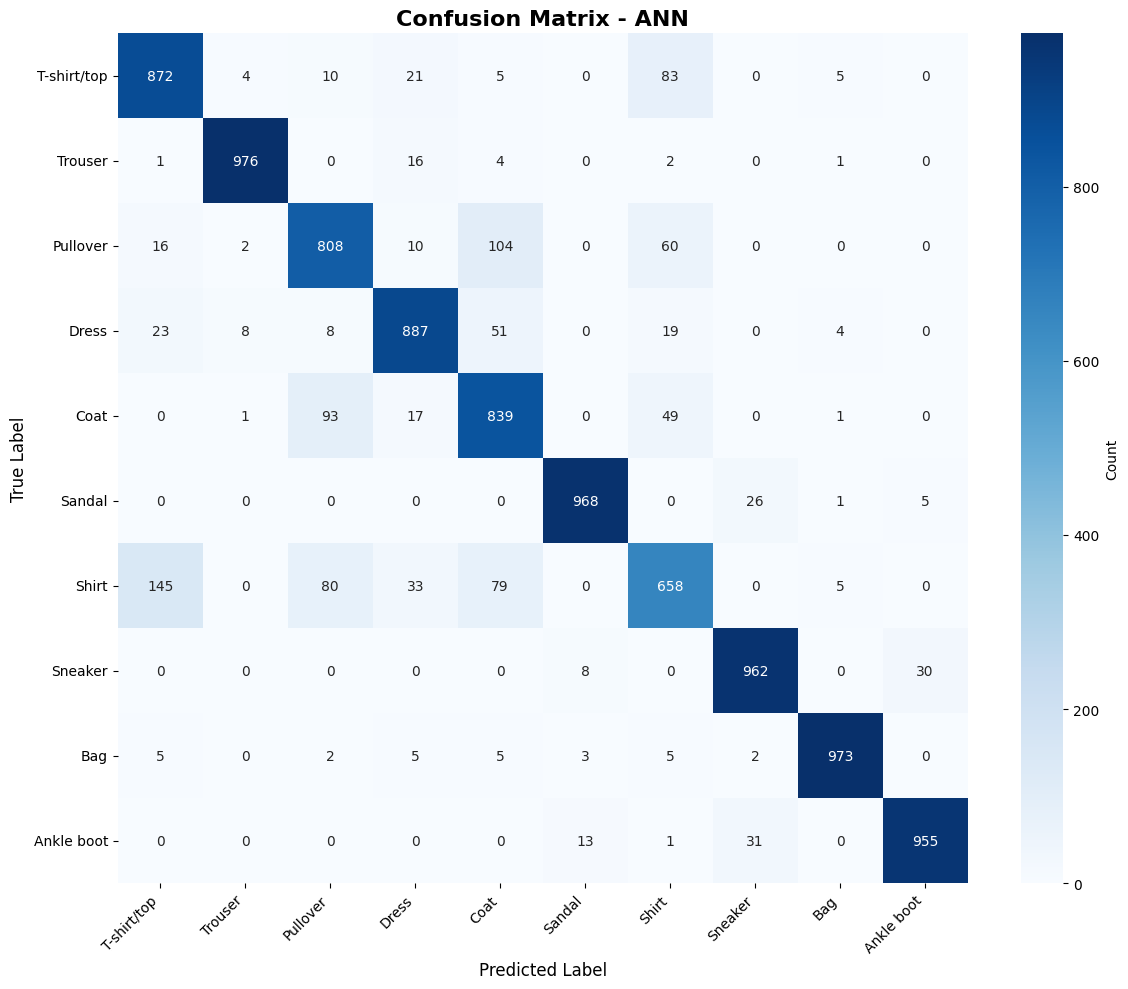


ANN - Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.82      0.87      0.85      1000
     Trouser       0.98      0.98      0.98      1000
    Pullover       0.81      0.81      0.81      1000
       Dress       0.90      0.89      0.89      1000
        Coat       0.77      0.84      0.80      1000
      Sandal       0.98      0.97      0.97      1000
       Shirt       0.75      0.66      0.70      1000
     Sneaker       0.94      0.96      0.95      1000
         Bag       0.98      0.97      0.98      1000
  Ankle boot       0.96      0.95      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000


ANN - Per-Class Accuracy:
T-shirt/top    : 87.20%
Trouser        : 97.60%
Pullover       : 80.80%
Dress          : 88.70%
Coat           : 83.90%
Sandal         : 96.80%
Shirt          : 65.80%
Sneaker        :

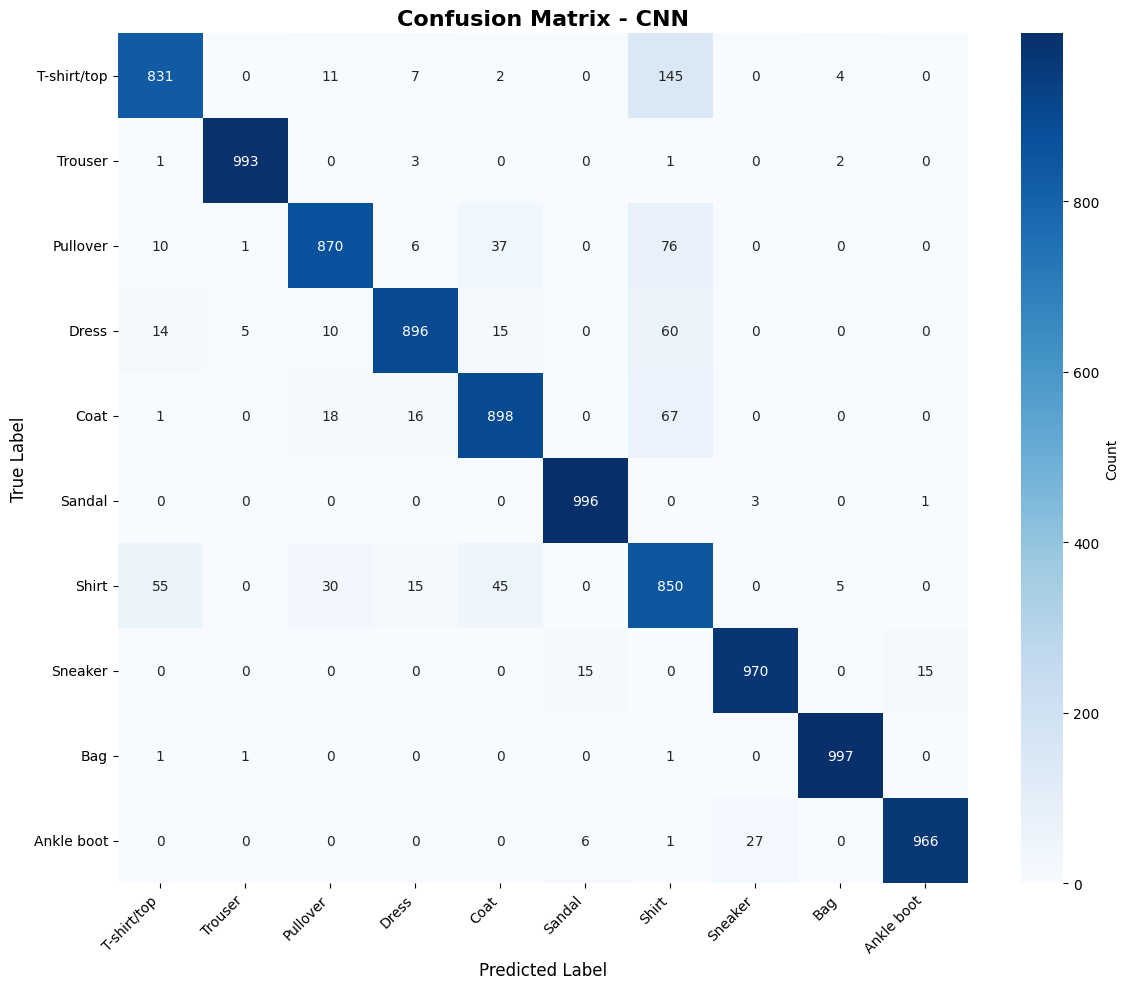


CNN - Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.91      0.83      0.87      1000
     Trouser       0.99      0.99      0.99      1000
    Pullover       0.93      0.87      0.90      1000
       Dress       0.95      0.90      0.92      1000
        Coat       0.90      0.90      0.90      1000
      Sandal       0.98      1.00      0.99      1000
       Shirt       0.71      0.85      0.77      1000
     Sneaker       0.97      0.97      0.97      1000
         Bag       0.99      1.00      0.99      1000
  Ankle boot       0.98      0.97      0.97      1000

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000


CNN - Per-Class Accuracy:
T-shirt/top    : 83.10%
Trouser        : 99.30%
Pullover       : 87.00%
Dress          : 89.60%
Coat           : 89.80%
Sandal         : 99.60%
Shirt          : 85.00%
Sneaker        :

In [61]:
def plot_confusion_matrix(model, X, y_true, class_names, model_name):
    """Generate and plot confusion matrix"""
    y_pred = np.argmax(model.predict(X, verbose=0), axis=1)
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={'label': 'Count'})
    plt.title(f'Confusion Matrix - {model_name}', fontsize=16, fontweight='bold')
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(f'confusion_matrix_{model_name.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Classification report
    print(f"\n{model_name} - Classification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))

    # Per-class accuracy
    per_class_acc = cm.diagonal() / cm.sum(axis=1)
    print(f"\n{model_name} - Per-Class Accuracy:")
    for i, acc in enumerate(per_class_acc):
        print(f"{class_names[i]:15s}: {acc*100:.2f}%")

    return cm, y_pred

print("7. GENERATING CONFUSION MATRICES")

cm_ann, pred_ann = plot_confusion_matrix(ann_model, X_test_flat, y_test,
                                         class_names, 'ANN')
cm_cnn, pred_cnn = plot_confusion_matrix(cnn_model, X_test_cnn, y_test,
                                         class_names, 'CNN')

In [62]:
print("PER-CLASS ACCURACY IMPROVEMENT (CNN vs ANN)")

ann_per_class = cm_ann.diagonal() / cm_ann.sum(axis=1) * 100
cnn_per_class = cm_cnn.diagonal() / cm_cnn.sum(axis=1) * 100
improvement = cnn_per_class - ann_per_class

improvement_df = pd.DataFrame({
    'Class': class_names,
    'ANN Accuracy': [f'{x:.2f}%' for x in ann_per_class],
    'CNN Accuracy': [f'{x:.2f}%' for x in cnn_per_class],
    'Improvement': [f'{x:+.2f}%' for x in improvement]
})

print(improvement_df.to_string(index=False))
print(f"\nBiggest improvement: {class_names[improvement.argmax()]} ({improvement.max():.2f}%)")
print(f"Only class worse: {class_names[improvement.argmin()]} ({improvement.min():.2f}%)" if improvement.min() < 0 else "CNN better on ALL classes!")

PER-CLASS ACCURACY IMPROVEMENT (CNN vs ANN)
      Class ANN Accuracy CNN Accuracy Improvement
T-shirt/top       87.20%       83.10%      -4.10%
    Trouser       97.60%       99.30%      +1.70%
   Pullover       80.80%       87.00%      +6.20%
      Dress       88.70%       89.60%      +0.90%
       Coat       83.90%       89.80%      +5.90%
     Sandal       96.80%       99.60%      +2.80%
      Shirt       65.80%       85.00%     +19.20%
    Sneaker       96.20%       97.00%      +0.80%
        Bag       97.30%       99.70%      +2.40%
 Ankle boot       95.50%       96.60%      +1.10%

Biggest improvement: Shirt (19.20%)
Only class worse: T-shirt/top (-4.10%)


### 8. TRAINING HISTORY VISUALIZATION

8. VISUALIZING TRAINING HISTORY


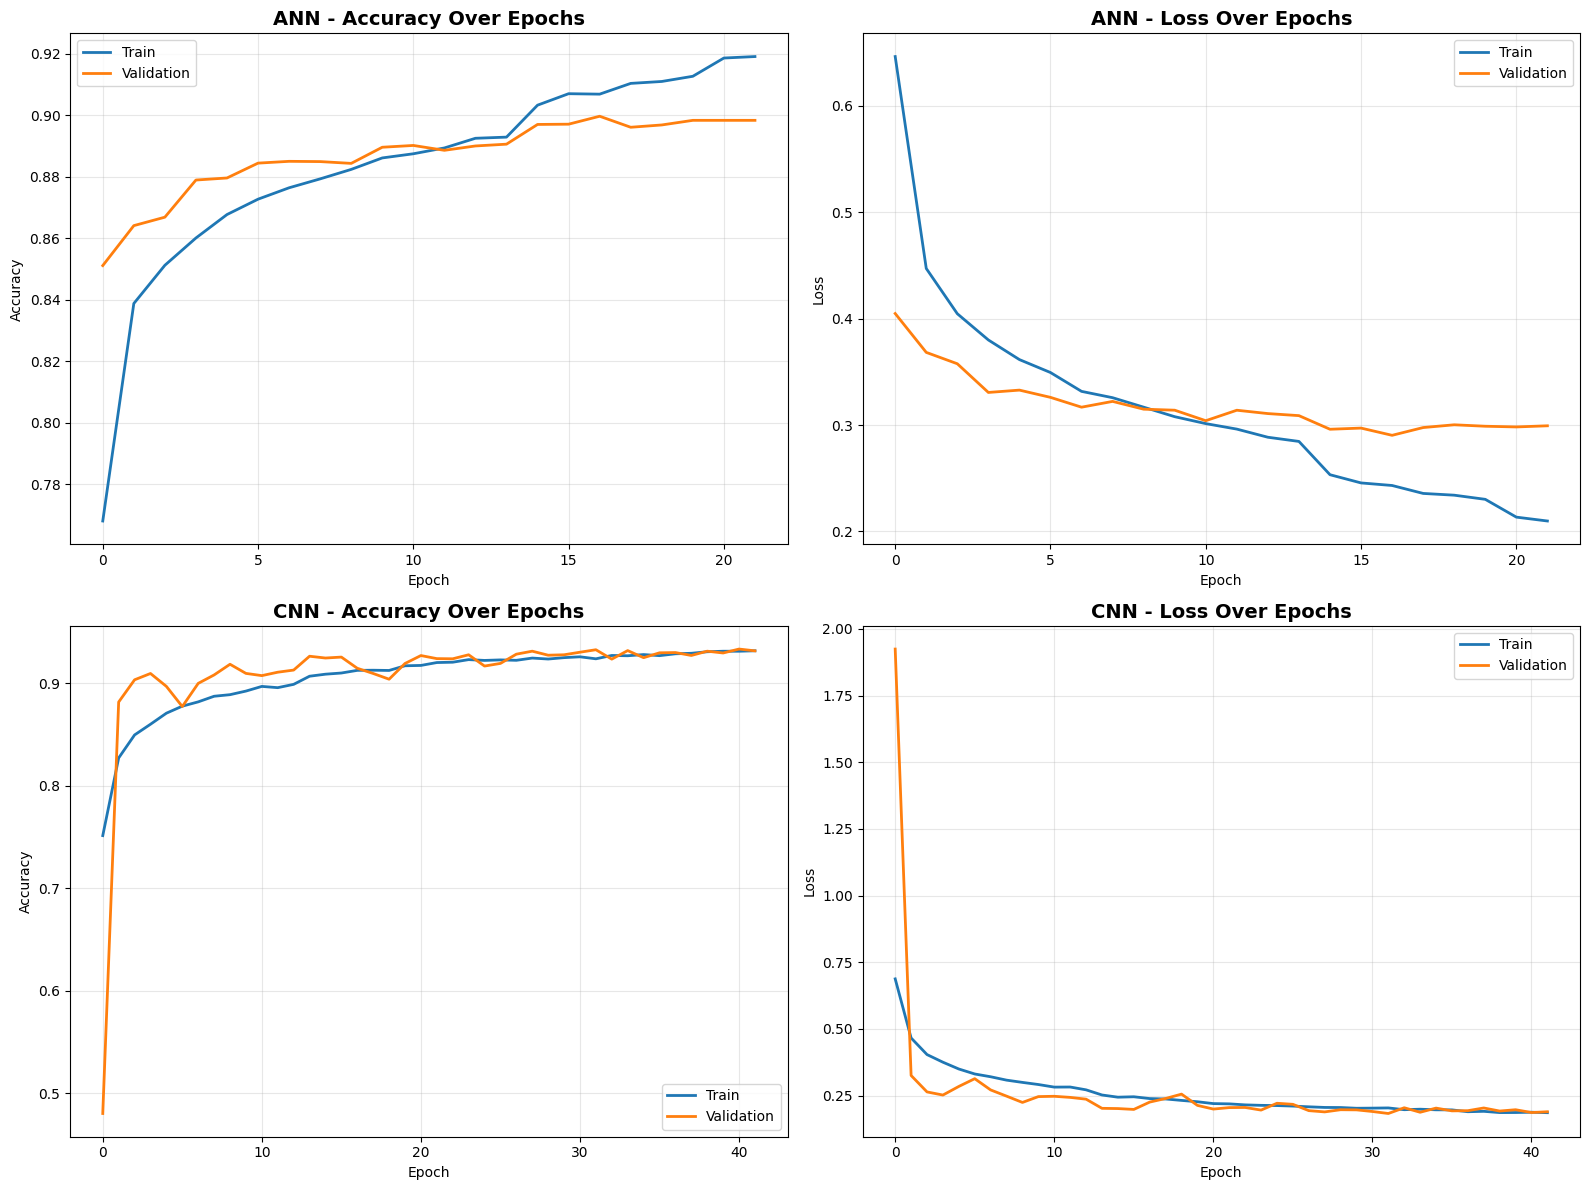

Training history plots saved as 'training_history.png'


In [63]:
def plot_training_history(history_ann, history_cnn):
    """Plot training and validation accuracy/loss curves"""
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # ANN - Accuracy
    axes[0, 0].plot(history_ann.history['accuracy'], label='Train', linewidth=2)
    axes[0, 0].plot(history_ann.history['val_accuracy'], label='Validation', linewidth=2)
    axes[0, 0].set_title('ANN - Accuracy Over Epochs', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Accuracy')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # ANN - Loss
    axes[0, 1].plot(history_ann.history['loss'], label='Train', linewidth=2)
    axes[0, 1].plot(history_ann.history['val_loss'], label='Validation', linewidth=2)
    axes[0, 1].set_title('ANN - Loss Over Epochs', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # CNN - Accuracy
    axes[1, 0].plot(history_cnn.history['accuracy'], label='Train', linewidth=2)
    axes[1, 0].plot(history_cnn.history['val_accuracy'], label='Validation', linewidth=2)
    axes[1, 0].set_title('CNN - Accuracy Over Epochs', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Accuracy')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    # CNN - Loss
    axes[1, 1].plot(history_cnn.history['loss'], label='Train', linewidth=2)
    axes[1, 1].plot(history_cnn.history['val_loss'], label='Validation', linewidth=2)
    axes[1, 1].set_title('CNN - Loss Over Epochs', fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Loss')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
    plt.show()

print("8. VISUALIZING TRAINING HISTORY")

plot_training_history(history_ann, history_cnn)
print("Training history plots saved as 'training_history.png'")

## 9. ERROR ANALYSIS - CONFUSED CLASSES

In [64]:
def analyze_confused_classes(cm, class_names, model_name):
    """Identify most confused class pairs"""
    print(f"\n{model_name} - Most Confused Class Pairs:")

    confused_pairs = []
    n_classes = len(class_names)

    for i in range(n_classes):
        for j in range(n_classes):
            if i != j and cm[i, j] > 0:
                confused_pairs.append((class_names[i], class_names[j], cm[i, j]))

    confused_pairs.sort(key=lambda x: x[2], reverse=True)

    for true_class, pred_class, count in confused_pairs[:10]:
        print(f"{true_class:15s} → {pred_class:15s}: {count:4d} samples")

    return confused_pairs

print("9. ERROR ANALYSIS - CONFUSED CLASSES")

confused_ann = analyze_confused_classes(cm_ann, class_names, 'ANN')
confused_cnn = analyze_confused_classes(cm_cnn, class_names, 'CNN')

9. ERROR ANALYSIS - CONFUSED CLASSES

ANN - Most Confused Class Pairs:
Shirt           → T-shirt/top    :  145 samples
Pullover        → Coat           :  104 samples
Coat            → Pullover       :   93 samples
T-shirt/top     → Shirt          :   83 samples
Shirt           → Pullover       :   80 samples
Shirt           → Coat           :   79 samples
Pullover        → Shirt          :   60 samples
Dress           → Coat           :   51 samples
Coat            → Shirt          :   49 samples
Shirt           → Dress          :   33 samples

CNN - Most Confused Class Pairs:
T-shirt/top     → Shirt          :  145 samples
Pullover        → Shirt          :   76 samples
Coat            → Shirt          :   67 samples
Dress           → Shirt          :   60 samples
Shirt           → T-shirt/top    :   55 samples
Shirt           → Coat           :   45 samples
Pullover        → Coat           :   37 samples
Shirt           → Pullover       :   30 samples
Ankle boot      → Sneaker      

## 10. VISUALIZE MISCLASSIFICATIONS

10. VISUALIZING MISCLASSIFICATIONS


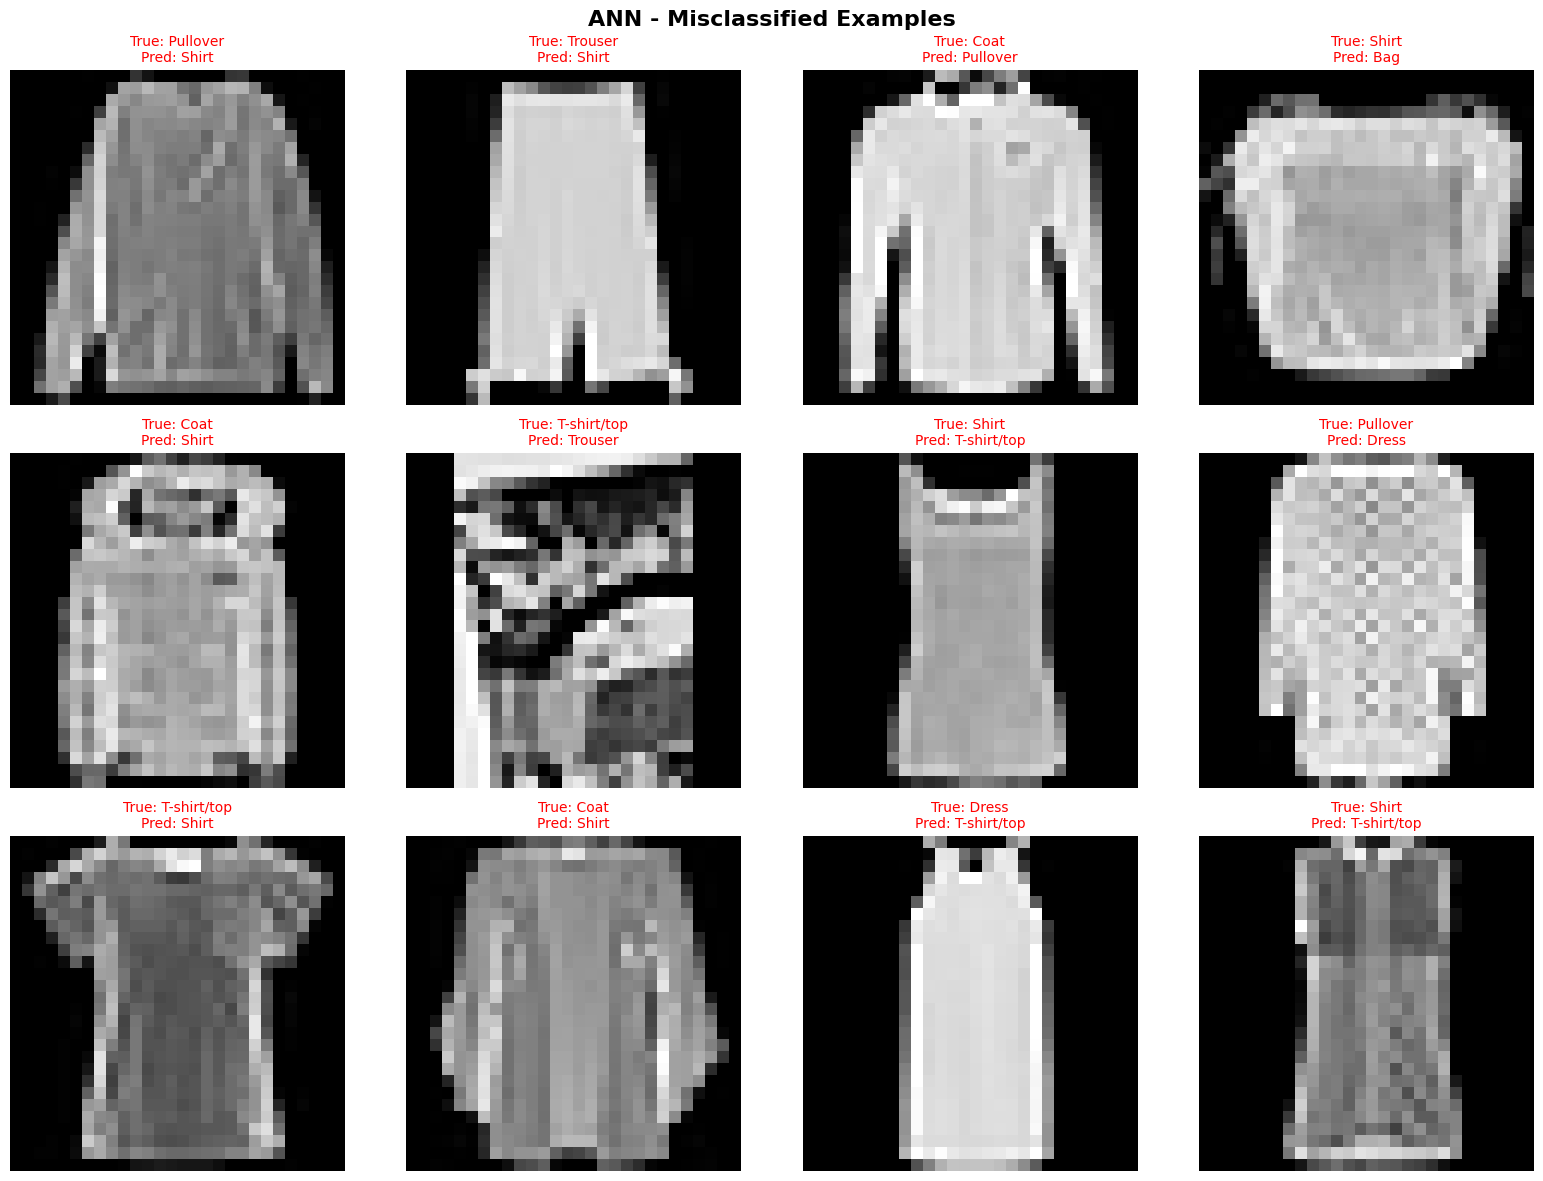

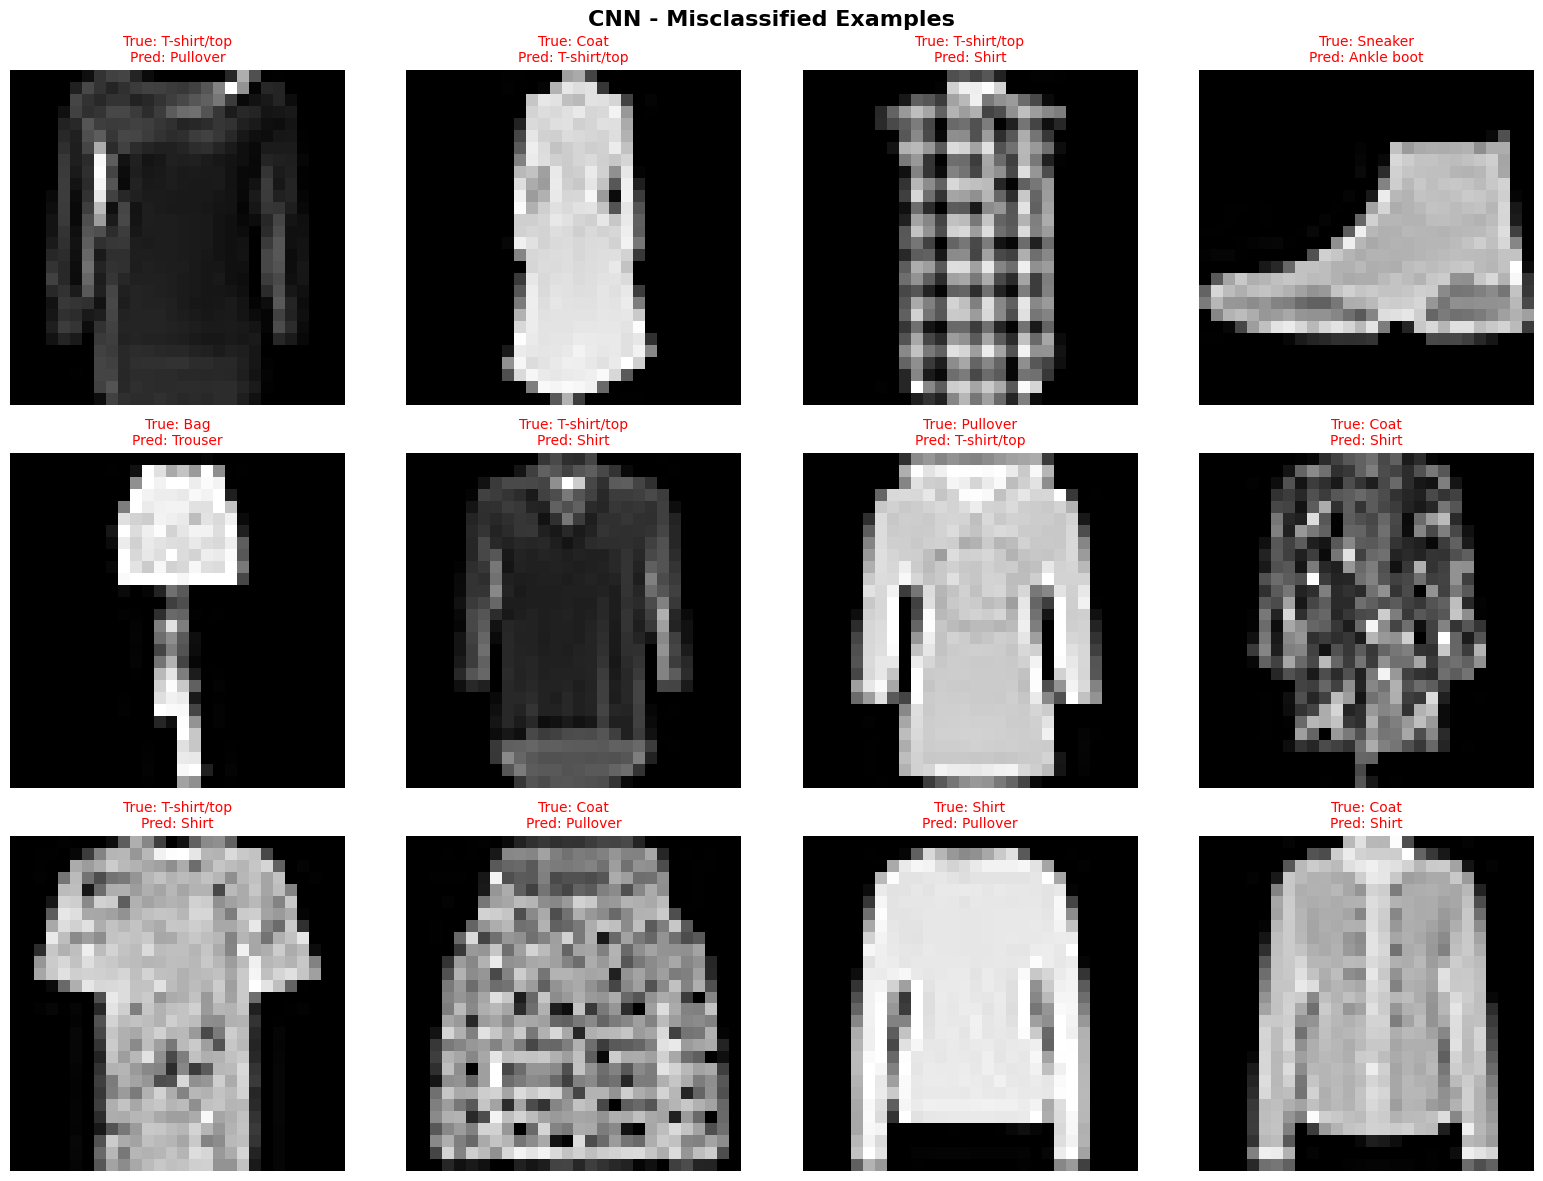

In [65]:
def visualize_misclassifications(model, X, y_true, y_pred, class_names, model_name, n_samples=12):
    """Visualize examples of misclassified images"""
    misclassified_idx = np.where(y_pred != y_true)[0]

    if len(misclassified_idx) == 0:
        print(f"No misclassifications found for {model_name}!")
        return

    sample_idx = np.random.choice(misclassified_idx,
                                  min(n_samples, len(misclassified_idx)),
                                  replace=False)

    plt.figure(figsize=(16, 12))
    for i, idx in enumerate(sample_idx):
        plt.subplot(3, 4, i + 1)
        if len(X.shape) == 4:  # CNN format
            plt.imshow(X[idx].squeeze(), cmap='gray')
        else:  # ANN format
            plt.imshow(X[idx].reshape(28, 28), cmap='gray')

        true_label = class_names[y_true[idx]]
        pred_label = class_names[y_pred[idx]]
        plt.title(f"True: {true_label}\nPred: {pred_label}", fontsize=10, color='red')
        plt.axis('off')

    plt.suptitle(f'{model_name} - Misclassified Examples', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'misclassifications_{model_name.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()

print("10. VISUALIZING MISCLASSIFICATIONS")

visualize_misclassifications(ann_model, X_test_flat, y_test, pred_ann, class_names, 'ANN')
visualize_misclassifications(cnn_model, X_test_cnn, y_test, pred_cnn, class_names, 'CNN')

In [66]:
# Add before final summary:
print("HYPERPARAMETER CONFIGURATION")

hyperparams = pd.DataFrame({
    'Parameter': ['Architecture', 'Optimizer', 'Learning Rate',
                  'Batch Size', 'Dropout', 'Data Augmentation'],
    'ANN': ['784-512-256-128-10', 'Adam', '0.001', '128',
            '0.3, 0.3, 0.2', 'No'],
    'CNN': ['Conv32-Conv32-Conv64-Conv64-Dense256', 'Adam', '0.001',
            '128', '0.25, 0.25, 0.4', 'Yes (rotation, shift, zoom)']
})
print(hyperparams.to_string(index=False))

HYPERPARAMETER CONFIGURATION
        Parameter                ANN                                  CNN
     Architecture 784-512-256-128-10 Conv32-Conv32-Conv64-Conv64-Dense256
        Optimizer               Adam                                 Adam
    Learning Rate              0.001                                0.001
       Batch Size                128                                  128
          Dropout      0.3, 0.3, 0.2                      0.25, 0.25, 0.4
Data Augmentation                 No          Yes (rotation, shift, zoom)


## 11. FINAL MODEL COMPARISON SUMMARY

In [67]:
print("11. FINAL MODEL COMPARISON SUMMARY")

comparison_df = pd.DataFrame({
    'Metric': ['Test Accuracy', 'Test Loss', 'Total Parameters',
               'Training Epochs', 'Best Validation Accuracy'],
    'ANN': [
        f"{ann_test_acc*100:.2f}%",
        f"{ann_test_loss:.4f}",
        f"{ann_model.count_params():,}",
        f"{len(history_ann.history['loss'])} epochs",
        f"{max(history_ann.history['val_accuracy'])*100:.2f}%"
    ],
    'CNN': [
        f"{cnn_test_acc*100:.2f}%",
        f"{cnn_test_loss:.4f}",
        f"{cnn_model.count_params():,}",
        f"{len(history_cnn.history['loss'])} epochs",
        f"{max(history_cnn.history['val_accuracy'])*100:.2f}%"
    ]
})

print("\n", comparison_df.to_string(index=False))

11. FINAL MODEL COMPARISON SUMMARY

                   Metric       ANN       CNN
           Test Accuracy    88.98%    92.67%
               Test Loss    0.3168    0.1979
        Total Parameters   567,434   872,426
         Training Epochs 22 epochs 42 epochs
Best Validation Accuracy    89.97%    93.32%


In [68]:
print("KEY INSIGHTS")
# Calculating overall improvement using the test accuracies
overall_improvement = ((cnn_test_acc - ann_test_acc) / ann_test_acc) * 100
print(f"CNN outperforms ANN by {overall_improvement:+.2f}%")
print(f"CNN achieves {cnn_test_acc*100:.2f}% test accuracy")
print(f"Most confused classes (both models): Shirt ↔ T-shirt/top, Pullover ↔ Coat")
print(f"CNN better captures spatial patterns in images")
print(f"Data augmentation helps CNN generalize better")
print(f"Despite using 1.54x MORE parameters ({cnn_model.count_params():,} vs {ann_model.count_params():,}),")
print(f"CNN achieves {overall_improvement:+.2f}% better accuracy through efficient spatial feature learning")

KEY INSIGHTS
CNN outperforms ANN by +4.15%
CNN achieves 92.67% test accuracy
Most confused classes (both models): Shirt ↔ T-shirt/top, Pullover ↔ Coat
CNN better captures spatial patterns in images
Data augmentation helps CNN generalize better
Despite using 1.54x MORE parameters (872,426 vs 567,434),
CNN achieves +4.15% better accuracy through efficient spatial feature learning


In [69]:
# Save models
print("SAVING MODELS")

ann_model.save('fashion_mnist_ann_model.keras')
cnn_model.save('fashion_mnist_cnn_model.keras')
print(" Models saved successfully!")

SAVING MODELS
 Models saved successfully!


In [70]:
# Add to final summary section:
print("MODEL COMPLEXITY ANALYSIS")
print(f"ANN Parameters: {ann_model.count_params():,}")
print(f"CNN Parameters: {cnn_model.count_params():,}")
print(f"Parameter Ratio (CNN/ANN): {cnn_model.count_params()/ann_model.count_params():.2f}x")
print(f"\n CNN has {(cnn_model.count_params()-ann_model.count_params()):,} MORE parameters")
print(f"   but achieves {overall_improvement:+.2f}% better accuracy")
print(f"   = MORE efficient learning through spatial features!")

MODEL COMPLEXITY ANALYSIS
ANN Parameters: 567,434
CNN Parameters: 872,426
Parameter Ratio (CNN/ANN): 1.54x

 CNN has 304,992 MORE parameters
   but achieves +4.15% better accuracy
   = MORE efficient learning through spatial features!


In [71]:
print("IMPLEMENTATION COMPLETE")
print("\n Summary:")
print(f"   ANN: {ann_test_acc*100:.2f}% accuracy")
print(f"   CNN: {cnn_test_acc*100:.2f}% accuracy")
print(f"   Improvement: {overall_improvement:+.2f}%")
print("\n Generated Files:")
print("   - sample_images.png")
print("   - confusion_matrix_ann.png")
print("   - confusion_matrix_cnn.png")
print("   - training_history.png")
print("   - misclassifications_ann.png")
print("   - misclassifications_cnn.png")
print("   - fashion_mnist_ann_model.keras")
print("   - fashion_mnist_cnn_model.keras")

IMPLEMENTATION COMPLETE

 Summary:
   ANN: 88.98% accuracy
   CNN: 92.67% accuracy
   Improvement: +4.15%

 Generated Files:
   - sample_images.png
   - confusion_matrix_ann.png
   - confusion_matrix_cnn.png
   - training_history.png
   - misclassifications_ann.png
   - misclassifications_cnn.png
   - fashion_mnist_ann_model.keras
   - fashion_mnist_cnn_model.keras
